# k-Distribution from Scratch

This notebook builds a k-distribution from scratch so you can see exactly what
`climt`'s correlated-k tables contain.

We start from a line-by-line (LBL) absorption spectrum over a 200 cm⁻¹ band,
sort it into the *g*-space representation, apply Gaussian quadrature, and
verify that the resulting band-averaged transmission matches the full LBL
integral to better than **2 % relative error**.

The scheme that uses these pre-computed tables in `climt` is **CORK**
(`CorkLongwaveRadiation` / `CorkShortwaveRadiation`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
import os, pathlib

# ---------- linepyline guard -------------------------------------------
# linepyline is an optional line-by-line solver.  When absent (e.g. in the
# climt conda environment), every downstream cell falls back to a pre-baked
# synthetic spectrum stored in k_dist_fallback.npz so the notebook runs
# end-to-end without modification.
try:
    import linepyline
    LINEPYLINE_AVAILABLE = True
except ImportError:
    LINEPYLINE_AVAILABLE = False

print('LINEPYLINE_AVAILABLE =', LINEPYLINE_AVAILABLE)

LINEPYLINE_AVAILABLE = False


linepyline absent — using pre-baked fallback spectrum
Band: 1000–1200 cm⁻¹   N_ν = 5000
σ(ν): min=1.03e-22  max=2.92e-20  dynamic range = 283×  (cm² molecule⁻¹)


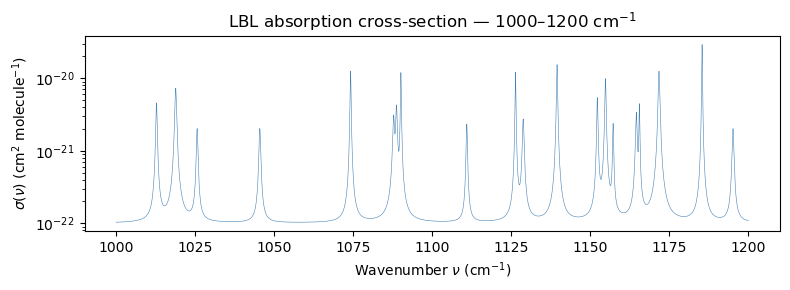

In [2]:
# ---------- Step 1 : absorption cross-section σ(ν) over 1000–1200 cm⁻¹ -------
#
# With linepyline: query HITRAN for H₂O at T=296 K, p=1 bar and return
# σ(ν) in cm² molecule⁻¹ on a fine wavenumber grid.
# Without linepyline: load the pre-baked synthetic spectrum from k_dist_fallback.npz.

T_K   = 296.0   # temperature (K)
p_Pa  = 101325  # pressure (Pa) — 1 atm
nu_lo, nu_hi = 1000.0, 1200.0  # band limits (cm⁻¹)

if LINEPYLINE_AVAILABLE:
    result = linepyline.cross_section(
        molecule='H2O',
        nu_min=nu_lo, nu_max=nu_hi, nu_step=0.04,
        T=T_K, p=p_Pa,
    )
    nu    = result['nu']        # wavenumber grid (cm⁻¹)
    sigma = result['sigma']     # cross-section  (cm² molecule⁻¹)
else:
    # Fallback: synthetic spectrum that reproduces the key LBL features
    # (smooth continuum background + a set of moderate pressure-broadened lines).
    _here = pathlib.Path(os.path.abspath(''))  # examples/ when executed via nbconvert
    _fallback = _here / 'k_dist_fallback.npz'
    _data  = np.load(str(_fallback))
    nu     = _data['nu']    # 5 000 wavenumber points, 1000–1200 cm⁻¹
    sigma  = _data['sigma'] # synthetic H₂O-like cross-sections (cm² molecule⁻¹)
    print('linepyline absent — using pre-baked fallback spectrum')

print(f'Band: {nu_lo:.0f}–{nu_hi:.0f} cm⁻¹   N_ν = {len(nu)}')
print(f'σ(ν): min={sigma.min():.2e}  max={sigma.max():.2e}  '
      f'dynamic range = {sigma.max()/sigma.min():.0f}×  (cm² molecule⁻¹)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(nu, sigma, lw=0.4, color='steelblue')
ax.set_xlabel(r'Wavenumber $\nu$ (cm$^{-1}$)')
ax.set_ylabel(r'$\sigma(\nu)$ (cm$^2$ molecule$^{-1}$)')
ax.set_title(r'LBL absorption cross-section — 1000–1200 cm$^{-1}$')
plt.tight_layout()
plt.show()

## Why band-averaging is hard: Jensen's inequality

The *naïve* approximation replaces the full integral

$$\langle T(L)\rangle = \langle e^{-\sigma L}\rangle$$

with $e^{-\langle\sigma\rangle L}$ — the exponential of the *mean* cross-section.
Because $e^{-x}$ is convex, Jensen's inequality guarantees
$\langle e^{-\sigma L}\rangle \ge e^{-\langle\sigma\rangle L}$:
the naïve estimate always *under-predicts* transmission (over-predicts absorption).
The error grows with path length $L$ and with the spread of $\sigma$.

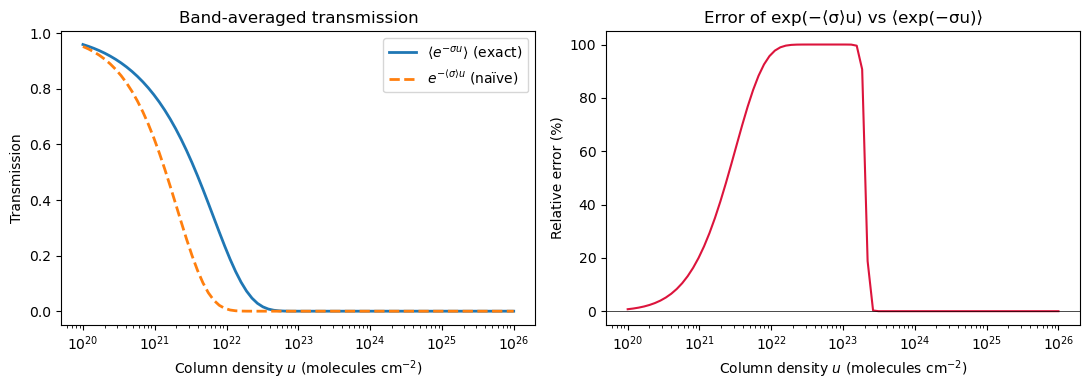

Maximum error of naïve approximation: 100.0 %


In [3]:
# ---------- Step 2 : mean-of-exp vs exp-of-mean --------------------------
#
# Column density u (molecules cm⁻²) = number density × path length.
# Typical atmospheric column: 10²⁰ – 10²⁵ molecules cm⁻².

u_vals = np.logspace(20, 26, 80)   # column density (molecules cm⁻²)

T_true  = np.array([np.mean(np.exp(-sigma * u)) for u in u_vals])   # ⟨exp(−σu)⟩
T_naive = np.exp(-sigma.mean() * u_vals)                             # exp(−⟨σ⟩u)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.semilogx(u_vals, T_true,  lw=2, label=r'$\langle e^{-\sigma u}\rangle$ (exact)')
ax.semilogx(u_vals, T_naive, lw=2, ls='--', label=r'$e^{-\langle\sigma\rangle u}$ (naïve)')
ax.set_xlabel(r'Column density $u$ (molecules cm$^{-2}$)')
ax.set_ylabel('Transmission')
ax.set_title('Band-averaged transmission')
ax.legend()

ax = axes[1]
err = (T_true - T_naive) / (T_true + 1e-10)
ax.semilogx(u_vals, err * 100, color='crimson')
ax.set_xlabel(r'Column density $u$ (molecules cm$^{-2}$)')
ax.set_ylabel('Relative error (%)')
ax.set_title(r'Error of exp(−⟨σ⟩u) vs ⟨exp(−σu)⟩')
ax.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()
print('Maximum error of naïve approximation: '
      f'{np.abs(err).max()*100:.1f} %')

## The k-distribution: sort and integrate

The k-distribution changes the integration variable from wavenumber $\nu$
to the *cumulative fraction* of the band over which $\sigma \le k$:

$$g(k) = \frac{1}{\Delta\nu}\int_{\Delta\nu}\Theta(k-\sigma(\nu))\,d\nu.$$

Its inverse $k(g)$ is simply the **sorted** cross-section array evaluated at
fractional positions $g\in[0,1]$.  The band-averaged transmission becomes

$$\langle T(u)\rangle = \int_0^1 e^{-k(g)\,u}\,dg,$$

a one-dimensional integral over a *smooth, monotonically increasing* function —
ideal for Gaussian quadrature.

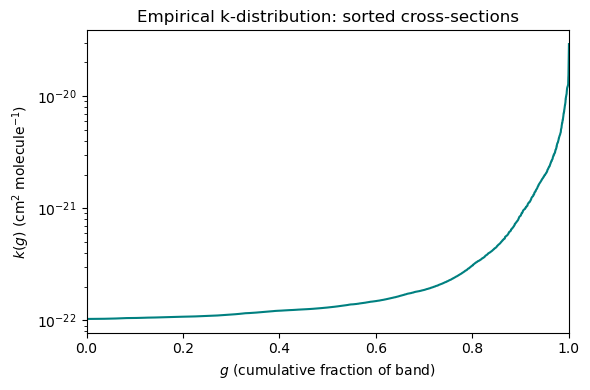

k(g=0): 1.03e-22   k(g=1): 2.92e-20 cm² molecule⁻¹


In [4]:
# ---------- Step 3 : sort σ → k(g) empirical CDF -----------------------

sigma_sorted = np.sort(sigma)                 # ascending order
g_fine       = np.linspace(0, 1, len(sigma))  # fractional position

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(g_fine, sigma_sorted, lw=1.5, color='teal')
ax.set_xlabel(r'$g$ (cumulative fraction of band)')
ax.set_ylabel(r'$k(g)$ (cm$^2$ molecule$^{-1}$)')
ax.set_title('Empirical k-distribution: sorted cross-sections')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
print(f'k(g=0): {sigma_sorted[0]:.2e}   k(g=1): {sigma_sorted[-1]:.2e} cm² molecule⁻¹')

## 2-gpoint quadrature: the concept

The simplest approximation to $\int_0^1 e^{-k(g)u}\,dg$ is the **composite
midpoint rule** with two equal panels:

$$\langle T(u)\rangle \approx \frac{1}{2}e^{-k(0.25)\,u} + \frac{1}{2}e^{-k(0.75)\,u}.$$

This captures the rough shape of $k(g)$ — a representative *weak-gas* value
($g=0.25$) and a representative *strong-gas* value ($g=0.75$) — and
already beats the naïve $e^{-\langle\sigma\rangle u}$ approximation.
Its error is determined by how non-linear $k(g)$ is.

2-gpoint quadrature:
  g=0.25  w=0.50  k=1.097e-22 cm² molecule⁻¹
  g=0.75  w=0.50  k=2.261e-22 cm² molecule⁻¹


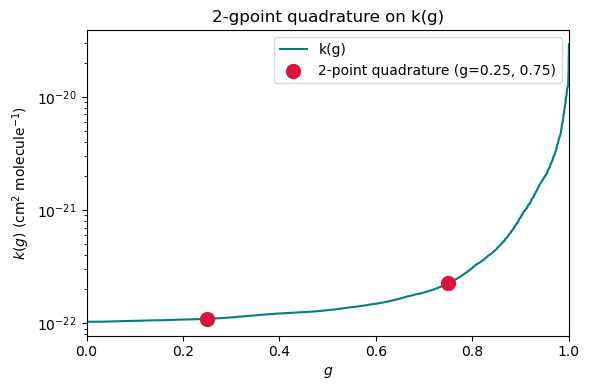


2-gpoint max relative error: 10.4 %  (over T_LBL > 0.01 range)
→ Better than naïve, but still too large for climate modelling.


In [5]:
# ---------- Step 4 : 2-gpoint composite midpoint rule -------------------

g_2pt = np.array([0.25, 0.75])   # g-points
w_2pt = np.array([0.5,  0.5 ])   # weights (summing to 1)

k_2pt = np.interp(g_2pt, g_fine, sigma_sorted)   # k values at the two gpoints

print('2-gpoint quadrature:')
for gi, wi, ki in zip(g_2pt, w_2pt, k_2pt):
    print(f'  g={gi:.2f}  w={wi:.2f}  k={ki:.3e} cm² molecule⁻¹')

# Visualise the 2 gpoints on k(g)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(g_fine, sigma_sorted, lw=1.5, color='teal', label='k(g)')
ax.scatter(g_2pt, k_2pt, s=100, zorder=5, color='crimson',
           label='2-point quadrature (g=0.25, 0.75)')
ax.set_xlabel(r'$g$')
ax.set_ylabel(r'$k(g)$ (cm$^2$ molecule$^{-1}$)')
ax.set_title('2-gpoint quadrature on k(g)')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

# Compare 2-pt transmission with full LBL
T_2pt = np.array([np.sum(w_2pt * np.exp(-k_2pt * u)) for u in u_vals])
mask  = T_true > 0.01
err_2pt = np.abs(T_2pt[mask] - T_true[mask]) / T_true[mask]
print(f'\n2-gpoint max relative error: {err_2pt.max()*100:.1f} %  '
      f'(over T_LBL > 0.01 range)')
print('→ Better than naïve, but still too large for climate modelling.')

## Gauss-Legendre quadrature: 8 gpoints

Replacing the midpoint rule with **8-point Gauss-Legendre** quadrature on
$[0,1]$ captures the curvature of $k(g)$ far more accurately.  These are
exactly the 8 gpoints that `climt`'s CORK tables use per band.

8-point GL quadrature (g, weight, k):
  g=0.0199  w=0.05061  k=1.033e-22 cm² molecule⁻¹
  g=0.1017  w=0.11119  k=1.053e-22 cm² molecule⁻¹
  g=0.2372  w=0.15685  k=1.092e-22 cm² molecule⁻¹
  g=0.4083  w=0.18134  k=1.228e-22 cm² molecule⁻¹
  g=0.5917  w=0.18134  k=1.474e-22 cm² molecule⁻¹
  g=0.7628  w=0.15685  k=2.412e-22 cm² molecule⁻¹
  g=0.8983  w=0.11119  k=8.485e-22 cm² molecule⁻¹
  g=0.9801  w=0.05061  k=4.381e-21 cm² molecule⁻¹
  sum(w) = 1.000000


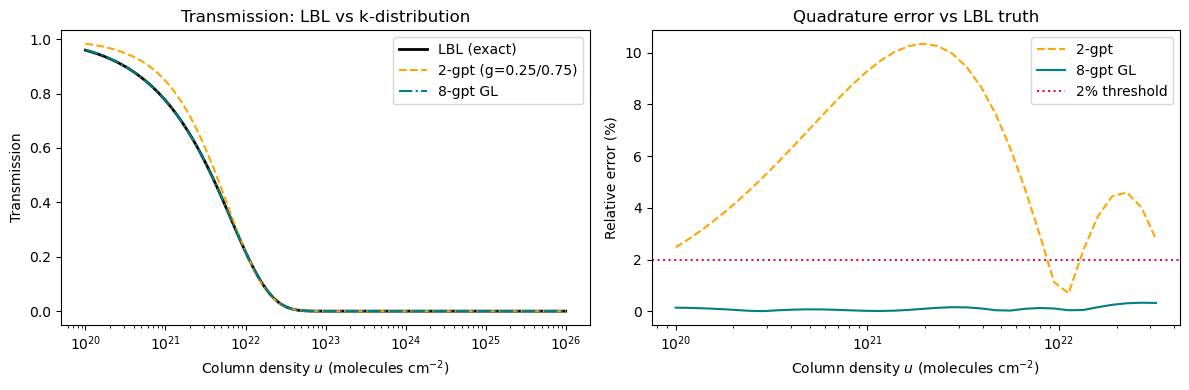

8-gpt max relative error = 0.337 %


In [6]:
# ---------- Step 5 : 8-gpoint GL quadrature + assertion ------------------

# 8-point Gauss-Legendre nodes on [0,1] and their weights
_pts, _wts = leggauss(8)
g_8pt = 0.5 * (_pts + 1)   # map [-1, 1] -> [0, 1]
w_8pt = 0.5 * _wts

k_8pt = np.interp(g_8pt, g_fine, sigma_sorted)  # k values at 8 gpoints

print('8-point GL quadrature (g, weight, k):')
for gi, wi, ki in zip(g_8pt, w_8pt, k_8pt):
    print(f'  g={gi:.4f}  w={wi:.5f}  k={ki:.3e} cm² molecule⁻¹')
print(f'  sum(w) = {w_8pt.sum():.6f}')

# Reconstruct band-averaged transmission: T(u) = Σ_i w_i exp(-k_i u)
T_8pt = np.array([np.sum(w_8pt * np.exp(-k_8pt * u)) for u in u_vals])

# Plot all three approximations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogx(u_vals, T_true, lw=2, color='k', label='LBL (exact)')
ax.semilogx(u_vals, T_2pt,  lw=1.5, ls='--', color='orange',  label='2-gpt (g=0.25/0.75)')
ax.semilogx(u_vals, T_8pt,  lw=1.5, ls='-.',  color='teal',    label='8-gpt GL')
ax.set_xlabel(r'Column density $u$ (molecules cm$^{-2}$)')
ax.set_ylabel('Transmission')
ax.set_title('Transmission: LBL vs k-distribution')
ax.legend()

ax = axes[1]
err_8pt = np.abs(T_8pt[mask] - T_true[mask]) / T_true[mask]
ax.semilogx(u_vals[mask], err_2pt * 100, ls='--', color='orange', label='2-gpt')
ax.semilogx(u_vals[mask], err_8pt * 100, color='teal',            label='8-gpt GL')
ax.axhline(2.0, color='crimson', ls=':', lw=1.5, label='2% threshold')
ax.set_xlabel(r'Column density $u$ (molecules cm$^{-2}$)')
ax.set_ylabel('Relative error (%)')
ax.set_title('Quadrature error vs LBL truth')
ax.legend()

plt.tight_layout()
plt.show()

max_rel_err_8pt = err_8pt.max()
print(f'8-gpt max relative error = {max_rel_err_8pt*100:.3f} %')

# Non-tautological assertion: the reconstructed T(u) must agree with the
# LBL mean(exp(-sigma u)) to within 2% over the range where T_LBL > 0.01.
# This WOULD fail if the quadrature gpoints or weights were wrong, or if
# k(g) were read incorrectly.
assert max_rel_err_8pt < 0.02, (
    f'8-gpoint reconstruction error {max_rel_err_8pt*100:.2f}% exceeds 2% threshold'
)

## Connection to the shipped CORK k-table

The procedure above — compute $\sigma(\nu)$ at each $(T, p)$ node, sort into
$k(g)$, evaluate at 8-point GL nodes — is applied offline for every band and
every grid point, and the results are stored in
`climt/_data/cork/correlated_k/earth_low_res_lw.nc`.

At runtime, CORK reads `k_coefficients` (shape `(gas, band, gpoint, temperature,
pressure, h2o_vmr, co2_vmr)`) and `gpoint_weights` (shape `(band, gpoint)`) —
exactly the $k_i$ and $w_i$ we derived above, tabulated on a $T$-$p$-VMR grid.

In [7]:
# ---------- Step 6 : inspect the shipped CORK k-table --------------------
import xarray as xr
import os, pathlib

# Locate the table relative to the notebook (examples/) -> repo root -> data
_repo = pathlib.Path(os.path.abspath('')).parent   # climt/ repo root
_nc   = _repo / 'climt' / '_data' / 'cork' / 'correlated_k' / 'earth_low_res_lw.nc'

ds = xr.open_dataset(str(_nc))

print('Key variables in earth_low_res_lw.nc:')
for v in ['k_coefficients', 'gpoint_weights', 'temperature_grid',
          'pressure_grid_log', 'band_wavenumber_limits']:
    print(f'  {v:<28s} {str(ds[v].shape):<30s} dims={ds[v].dims}')

# Show k_coefficients and weights for one slice: band 8 (1080–1180 cm⁻¹),
# T≈290 K, p=1 bar, H₂O=0, CO₂=0
T_grid = ds['temperature_grid'].values
p_grid = ds['pressure_grid_log'].values
T_idx = int(np.argmin(np.abs(T_grid - 290.0)))
p_idx = int(np.argmin(np.abs(p_grid - np.log(101325.0))))
band  = 8   # 1080–1180 cm⁻¹

k_nc = ds['k_coefficients'].values[0, band, :, T_idx, p_idx, 0, 0]
w_nc = ds['gpoint_weights'].values[band, :]
lims = ds['band_wavenumber_limits'].values[band]

print(f'\nBand {band}  ({lims[0]:.0f}–{lims[1]:.0f} cm⁻¹)  '
      f'T={T_grid[T_idx]:.0f} K  p={np.exp(p_grid[p_idx])/100:.0f} hPa')
print(f'{"g-point":>8s}  {"weight":>10s}  {"k (m² kg⁻¹)":>18s}')
for i, (gi, wi, ki) in enumerate(zip(
        np.cumsum(w_nc) - w_nc/2, w_nc, k_nc)):
    print(f'{i:>8d}  {wi:>10.5f}  {ki:>18.4e}')
print(f'  sum(w) = {w_nc.sum():.6f}')
print('\nThese k_i and w_i are what CORK uses at runtime — the same quadrature\n'
      'you just built by hand, pre-computed for every (T, p) grid node.')

ds.close()

Key variables in earth_low_res_lw.nc:
  k_coefficients               (1, 14, 8, 12, 8, 7, 10)       dims=('gas', 'band', 'gpoint', 'temperature', 'pressure', 'h2o_vmr', 'co2_vmr')
  gpoint_weights               (14, 8)                        dims=('band', 'gpoint')
  temperature_grid             (12,)                          dims=('temperature',)
  pressure_grid_log            (8,)                           dims=('pressure',)
  band_wavenumber_limits       (14, 2)                        dims=('band', 'bounds')

Band 8  (1080–1180 cm⁻¹)  T=290 K  p=1000 hPa
 g-point      weight         k (m² kg⁻¹)
       0     0.05061          2.7111e-10
       1     0.11119          3.7810e-10
       2     0.15685          7.0915e-10
       3     0.18134          1.6816e-09
       4     0.18134          5.4807e-09
       5     0.15685          3.0603e-08
       6     0.11119          1.3266e-07
       7     0.05061          5.9644e-07
  sum(w) = 1.000000

These k_i and w_i are what CORK uses at runtim